In [2]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/numpy/__init__.py
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py


In [3]:
import os
from neuron import h
print(f"Current Directory: {os.getcwd()}")
mt = h.MechanismType(0)
mname = h.ref('')
found = False
for i in range(int(mt.count())):
    mt.select(i)
    mt.selected(mname)
    if mname[0] == "stellate_mech":
        found = True
print(f"stellate_mech loaded: {found}")

Current Directory: /home/govind/gov_semproject/GridCellsTheta/GridCellsCond
stellate_mech loaded: True


In [4]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import stellate
import importlib
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)



0.0

In [5]:
mt = h.MechanismType(0)
mname = h.ref('')
for i in range(int(mt.count())):
    mt.select(i)
    mt.selected(mname)
    print(mname[0])

morphology
capacitance
pas
extracellular
fastpas
na_ion
k_ion
hh
i_theta
i_theta_stell
kdr
naf
stellate_mech


In [7]:
stellate_0 = stellate.Stellate(0)

stell_comb_ic = h.IClamp(stellate_0.soma(0.5))
stell_comb_ic.dur = 1e9

time_dur = 12000

time_steps = int(time_dur / h.dt)
time_arr = np.arange(0,time_dur,h.dt)

input_amp = -3.2e-3
theta_amp = 1e-4
theta_freq = 10.0

initial_phase = 2*np.pi*np.random.random()
mean,std=0,1e-5

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
input_rec = h.Vector().record(stell_comb_ic._ref_amp)

nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



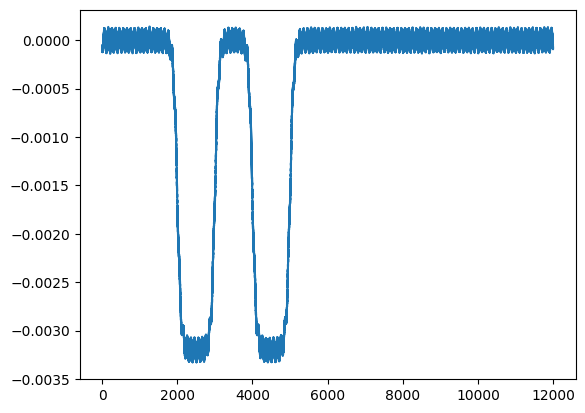

In [8]:
def input_func(t_ms):
    first_term = 0.5 * (np.tanh((t_ms - 2000)/100) - np.tanh((t_ms - 3000)/100))
    second_term = 0.5 * (np.tanh((t_ms - 4000)/100) - np.tanh((t_ms - 5000)/100))
    theta_term = theta_amp * np.sin(2 * np.pi * theta_freq * t_ms / 1000 + initial_phase)#*np.exp(-np.sin(2*np.pi*t_ms/1000))
    return (input_amp*(first_term + second_term)) + theta_term

noise_input = np.random.normal(0,std,time_steps)
stell_input = input_func(time_arr) + noise_input
plt.plot(time_arr,stell_input)
plt.show()

In [ ]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 0.01 
g_max = 0.005
g_theta_amp = 0.5
g_base = 0
theta_freq = 10.0    

def conductance_func(t_ms):

    mask = ((t_ms>=1900)&(t_ms<=3600)) | ((t_ms>=7900)&(t_ms<=9600))
    
    pulse_1 = 0.5 * (np.tanh((t_ms - 2000)/200) - np.tanh((t_ms - 3500)/200)) + 0.0008
    pulse_2 = 0.5 * (np.tanh((t_ms - 10500)/500) - np.tanh((t_ms - 12000)/500)) + 0.0008
    envelope = pulse_1 + pulse_2
    
    oscillations = g_theta_amp*(np.sin(np.pi * theta_freq * t_ms / 1000 + initial_phase))**2
    
    return (g_max * envelope * (0.5 + 0.5 * oscillations)) 

stell_g_input = conductance_func(time_arr)
stell_g_input += np.random.normal(0, 1e-5, len(time_arr))
stell_g_input = np.clip(stell_g_input, 0, None)

g_vec = h.Vector(stell_g_input)
g_vec.play(syn_inh._ref_g, h.dt)

g_rec = h.Vector().record(syn_inh._ref_g)

h.finitialize(-65)
h.frecord_init()
h.continuerun(time_dur)



0.0

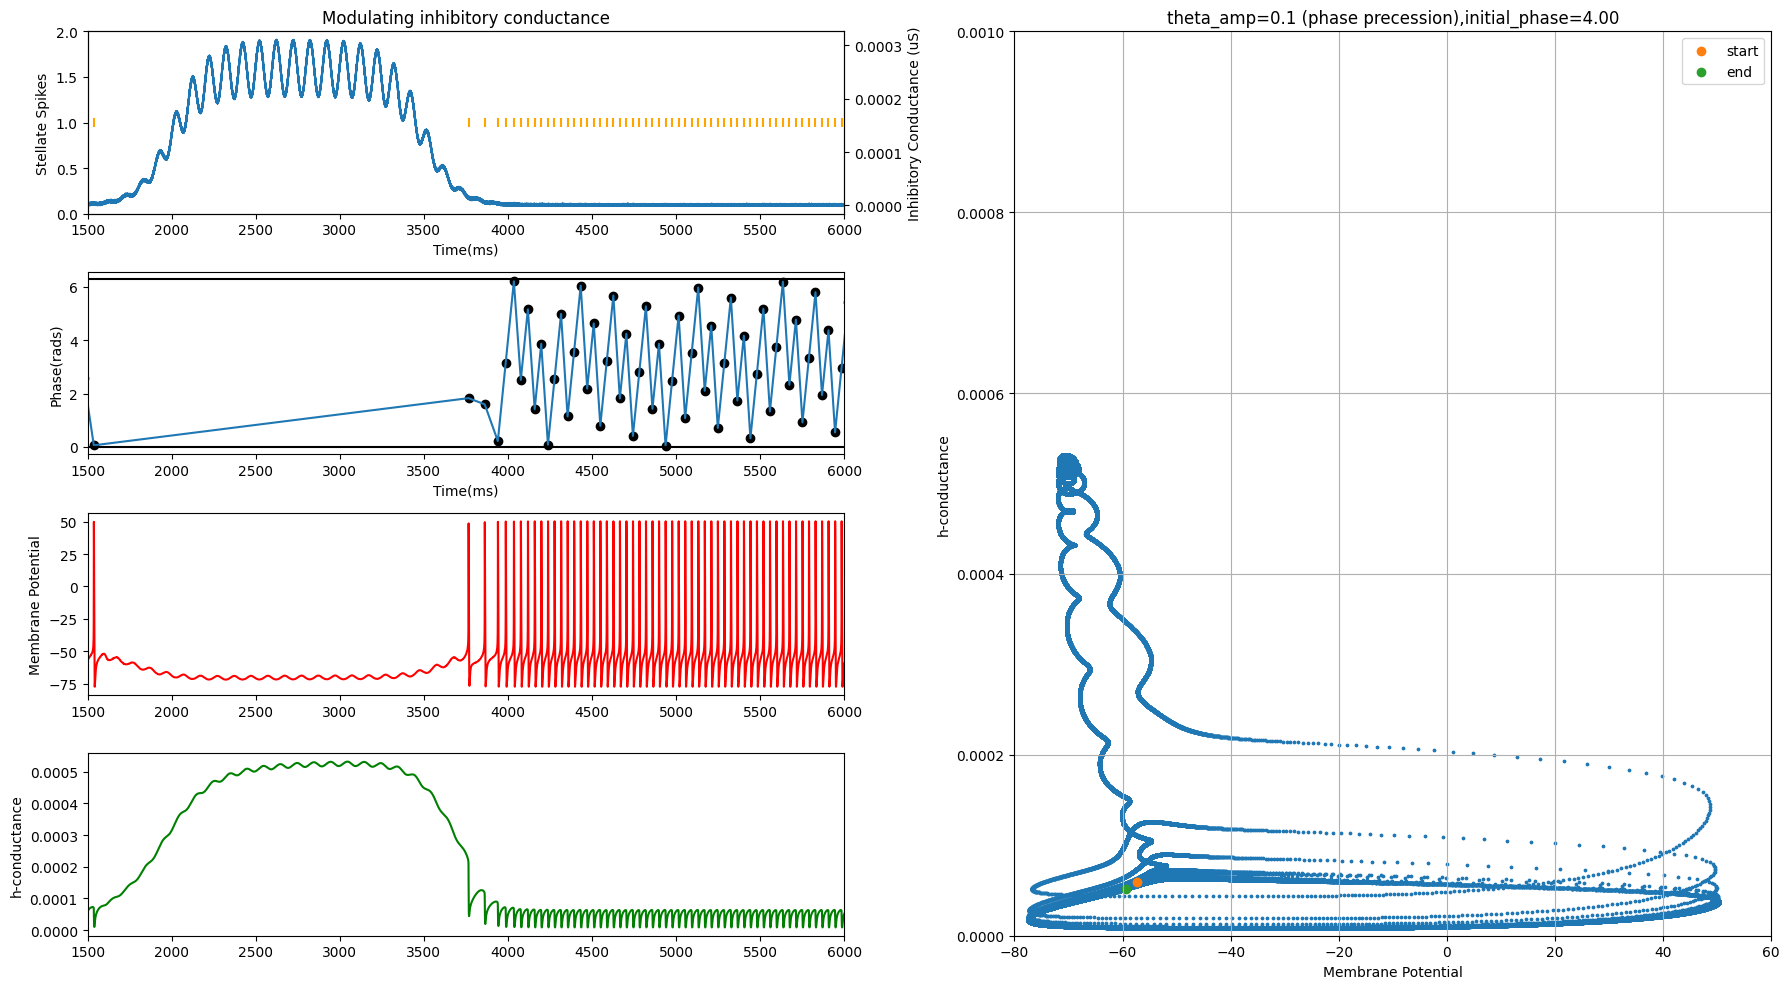

In [20]:

from matplotlib.gridspec import GridSpec

spike_times_array = np.array(spike_times_stell.to_python())
phases = (((spike_times_array) * theta_freq * 2 * np.pi / 1000) + initial_phase) % (2 * np.pi)
g_rec_array = np.array(g_rec.to_python())

volt_dyn = np.array(stell_v.to_python())
hcond_dyn = np.array(stellate_gh_vec.to_python())

start = 1500
end = 6000

fig = plt.figure(figsize=(18,10))
gs = GridSpec(4,2, width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])

ax0_twin = ax0.twinx()
ax0.eventplot(spike_times_array, label="Stellate Spikes", color='orange', linelengths=0.1)
ax0.set_ylim(0,2)
ax0.set_xlim(start,end)
ax0.set_ylabel('Stellate Spikes')
ax0.set_xlabel('Time(ms)')
ax0.set_title("Modulating inhibitory conductance")

ax0_twin.plot(time, g_rec_array, label="Input")
ax0_twin.set_ylabel('Inhibitory Conductance (uS)')

ax1.plot(spike_times_array, phases)
ax1.scatter(spike_times_array, phases, color='black')
ax1.set_xlabel("Time(ms)")
ax1.set_xlim(start,end)
ax1.set_ylabel("Phase(rads)")
ax1.axhline(y=2*np.pi, color='black')
ax1.axhline(y=0, color='black')

ax2.plot(time, stell_v, color='red')
ax2.set_ylabel("Membrane Potential")
ax2.set_xlim(start,end)
ax3.plot(time, stellate_gh_vec, color='green')
ax3.set_ylabel("h-conductance")
ax3.set_xlim(start,end)

ax_phase.scatter(volt_dyn[start*40:end*40], hcond_dyn[start*40:end*40], s=3)
ax_phase.scatter(volt_dyn[start*40], hcond_dyn[start*40], label='start')
ax_phase.scatter(volt_dyn[end*40], hcond_dyn[end*40], label='end')

ax_phase.set_xlabel("Membrane Potential")
ax_phase.set_ylabel("h-conductance")
ax_phase.set_title(f"theta_amp=0.1 (phase precession),initial_phase={initial_phase:.2f}")
ax_phase.set_ylim(0,0.001)
ax_phase.set_xlim(-80,60)
ax_phase.grid(True)
ax_phase.legend()

plt.tight_layout()
plt.show()

In [23]:
def phase_prec_rate(spike_times,spike_phases):
    times = np.array(spike_times)
    phi_unwrap = np.unwrap(spike_phases)
    beta, alpha = np.polyfit(times, phi_unwrap, 1)

    return beta
print(np.unwrap(phases))


[  2.41695921   4.10399446   6.54501196   9.18237899  11.75377258
  14.45868385  17.02065266  19.71613916  22.35350619  24.97359446
  27.6502314   30.22947897  32.9532398   35.55604932  38.20755351
  40.87476568  43.46815041  46.20290682  48.76487563  51.46350372
  54.0804504   56.7319546   59.38974198  61.98626831  64.71317073
  67.29870149  70.01932073  72.67396652  75.34432027  78.11677579
  80.79341273  83.81091247  86.64777064  84.11250537  86.57080162
  86.33046978  85.0801159   82.99881077  86.05715122  89.17832352
  91.93507107  94.73423013  97.46270335 100.0937872  102.8285436
 105.41721595 108.15354315 110.75006948 113.42670642 116.09548938
 118.67316615 121.40949335 123.97931614 126.68736901 129.29332011
 131.92440396 134.59475772 137.17871767 139.88519975 142.46601811
 145.11123913 147.7721681  150.37026523 153.06261013 155.62457894
 158.32791942 160.92915814 163.56495437 166.23844972 168.79727694
 171.50061741 174.072011   176.75650192 179.37030701 181.97468732
 184.690594